# Marketing Campaign Analytics - Data Profiling

## Objective

This notebook is intentionally limited to data profiling and data-quality diagnosis.

The purpose is to understand the raw dataset before any cleaning, transformation, imputation, correction, or feature engineering.


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv("marketing_campaign_data_messy.csv")

In [53]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [54]:
df.tail()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA
2019,CMP-01554,Q4_Launch_CMP-01554,2023-06-26 00:00:00,2023-07-09,Email,96402,1090,1315.59,66.0,Y,NaN,EM


In [55]:
df.shape

(2020, 12)

In [45]:
df.info()
# Findings from df.info():
# - Total entries: 2020.
# - Total columns: 12.
# - Data types: 8 object, 2 int64, 2 float64.
# - Missing values identified in:
#   - ' Channel': 101 missing values (1919 non-null).
#   - 'Conversions': 200 missing values (1820 non-null).
#   - 'Clicks' (the second one): 1980 missing values (only 40 non-null).
# - Column names with leading/trailing whitespace:
#   - ' Campaign_ID ' (leading and trailing space)
#   - 'Clicks ' (trailing space)
# - Inconsistent data types:
# - 'Start_Date' and 'End_Date' are currently stored as object type.
# - 'Spend' is currently stored as object type and contains mixed representations that require investigation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


In [46]:
df.describe()
# Findings from df.describe():
# - There are two columns named 'Clicks'. One has 2020 non-null values (likely original clicks), and the other has only 40 non-null values with significantly different statistics (much higher mean and max), indicating potential data entry error or a different metric.
# - 'Conversions' column has 200 missing values (count is 1820 out of 2020).
# - The numerical columns ('Impressions', 'Clicks', 'Conversions') show a wide range of values and distributions, with max values much higher than their respective means, suggesting potential outliers or skewed data.

,Impressions,Clicks,Conversions,Clicks
count,2020.000000,2020.000000,1820.000000,40.000000
mean,49839.896040,1500.744059,186.085714,54856.200000
std,28579.637473,1084.765654,160.129172,30552.773369
min,1055.000000,11.000000,0.000000,2508.000000
25%,25033.500000,650.750000,68.000000,30164.750000
50%,50097.500000,1245.000000,142.000000,57707.500000
75%,74784.250000,2185.250000,257.000000,81497.500000
max,99875.000000,4812.000000,943.000000,99483.000000


# Structural profiling - Column header and column records profiling.

In [47]:
df.columns.tolist()

[' Campaign_ID ',
 'Campaign_Name',
 'Start_Date',
 'End_Date',
 'Channel',
 'Impressions',
 'Clicks ',
 'Spend',
 'Conversions',
 'Active',
 'Clicks',
 'Campaign_Tag']

In [48]:
channel_values = df["Channel"].dropna().unique()

for value in sorted(channel_values):
    print(value)

E-mail
Email
Facebok
Facebook
Gogle
Google Ads
Insta_gram
Instagram
TikTok
Tik_Tok


In [49]:
campaign_name_check = (
    df.groupby(" Campaign_ID ")["Campaign_Name"]
      .nunique()
      .sort_values(ascending=False)
)

display(campaign_name_check.head(20))

,Campaign_Name
Campaign_ID,
CMP-01984,1
CMP-01983,1
CMP-01982,1
CMP-01981,1
CMP-01980,1
CMP-01979,1
CMP-01978,1
CMP-01977,1
CMP-01976,1


In [50]:
campaign_name_check[campaign_name_check > 1]

,Campaign_Name
Campaign_ID,


In [58]:
df["Campaign_Tag"].unique()

array(['TI', 'FA', 'EM', 'IN', 'GO', 'E-', 'INVALID', 'XX'], dtype=object)

'TIFAEMTIFAINFAINGOEMINGOGOTIGOE-EMINFAINVALIDFAGOGOINEMGOTIEMININGOININFAINTIINTIEMEMEMTIINE-TIINGOEMFAINVALIDGOTIFAXXGOFAEMTIFAEMGOGOFAEMEMTIGOFAEMEMTIEMGOE-TIEMGOEMGOFAEMTIININEMINVALIDININXXININGOGOXXTIGOEMXXINTITIGOXXEMTIGOGOGOTIINEMEMINFAFAFATIGOFAFAEMINFAXXEMEMININTIFAINVALIDGOFAFAGOGOGOFAININFATIFAGOFAGOFAINFAXXGOE-TITIINVALIDFATIINVALIDGOGOINVALIDGOINVALIDGOINTIGOFAGOTIXXFAEMTIEMTITIFAFAFAINEMEMEMFAINFAE-INFAINVALIDINFAFAEMININTIEMGOINEMFAININEMINFAINVALIDINTIFAFAEMTITIININVALIDTIINFATIFAGOINVALIDINEMEMEMTIINVALIDXXINTIINFAXXXXXXTIFAINFAFAINEMTIGOFAFATITIFATITIEMTITIGOINFAFAFATIGOGOEMEMINEMINTITIINTIEMEMTIFAE-EMFAININVALIDXXINININVALIDINVALIDINVALIDE-TIINTIGOFAFAGOXXGOEMINFAGOFAGOFATIGOEMEMINGOFAEMININGOTIFATIEMXXEMTIFAXXTIGOFAGOININFAEMTITIFAFAINEMTIGOEMTIEMGOGOGOFAGOINXXGOININFAGOTIININVALIDGOTIINFATIINGOEMGOGOGOINVALIDEMXXFAFAEMFAINVALIDFAXXEMXXFATIFATIGOINVALIDGOTIGOGOTIINVALIDTITIGOTITIEMININVALIDEMFAEMFAGOEMINVALIDINTITIGOGOTIFAGOTIGOTIINGOFAGOINVALIDGOINVALIDFAE-GOFATII

# Numeric column profiling

In [20]:
df["Spend"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2020 entries, 0 to 2019
Series name: Spend
Non-Null Count  Dtype 
--------------  ----- 
2020 non-null   object
dtypes: object(1)
memory usage: 15.9+ KB


In [21]:
df["Spend"].head(20)

,Spend
0,$102.82
1,24.33
2,1323.39
3,2180.38
4,252.44
5,2697.03
6,1232.76
7,865.7
8,1046.18
9,1623.56


In [22]:
df["Spend"].astype(str).str.contains(r"[$,]").sum()

np.int64(298)

In [23]:
df["Spend"].astype(str).str.strip().value_counts().head(20)

,count
Spend,
500000.0,5
883.82,2
1315.59,2
1371.03,2
1796.19,2
5093.82,2
$2640.72,2
$503.95,2
460.42,2


In [24]:
spend_numeric = pd.to_numeric(df['Spend'], errors='coerce')

In [25]:
spend_numeric.describe()

,Spend
count,1722.000000
mean,3307.144913
std,26860.112660
min,-2503.310000
25%,652.950000
50%,1429.380000
75%,2624.892500
max,500000.000000


In [26]:
spend_numeric.isna().sum()

np.int64(298)

In [27]:
spend_numeric[spend_numeric < 0].describe()

,Spend
count,19.000000
mean,-1015.200000
std,678.882126
min,-2503.310000
25%,-1334.675000
50%,-942.800000
75%,-599.415000
max,-20.050000


In [28]:
(spend_numeric < 0).sum()

np.int64(19)

In [29]:
spend_numeric.describe()

,Spend
count,1722.000000
mean,3307.144913
std,26860.112660
min,-2503.310000
25%,652.950000
50%,1429.380000
75%,2624.892500
max,500000.000000


In [30]:
spend_numeric.isna().sum()

np.int64(298)

In [31]:
spend_numeric[spend_numeric < 0].describe()

,Spend
count,19.000000
mean,-1015.200000
std,678.882126
min,-2503.310000
25%,-1334.675000
50%,-942.800000
75%,-599.415000
max,-20.050000


In [32]:
(spend_numeric < 0).sum()

np.int64(19)

In [33]:
df['Spend_numeric'] = pd.to_numeric(df['Spend'], errors='coerce')

In [34]:
df[['Spend', 'Spend_numeric']].head(20)

,Spend,Spend_numeric
0,$102.82,NaN
1,24.33,24.33
2,1323.39,1323.39
3,2180.38,2180.38
4,252.44,252.44
5,2697.03,2697.03
6,1232.76,1232.76
7,865.7,865.70
8,1046.18,1046.18
9,1623.56,1623.56


In [35]:
negative_spend = df[df['Spend_numeric'] < 0]

negative_spend

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag,Spend_numeric
144,CMP-00145,Q2_Summer_CMP-00145,2023-12-07 00:00:00,2023-12-14,Facebook,51636,1859,-1407.54,270.0,Y,NaN,FA,-1407.54
407,CMP-00408,Q1_BlackFriday_CMP-00408,2023-05-21 00:00:00,2023-05-28,Facebok,78575,2058,-1214.52,119.0,0,NaN,FA,-1214.52
576,CMP-00577,Q4_Launch_CMP-00577,2023-06-30 00:00:00,2023-07-13,Facebook,90084,940,-821.8,178.0,No,NaN,FA,-821.80
604,CMP-00605,Q2_BlackFriday_CMP-00605,2023-02-03 00:00:00,2023-02-25,Email,42555,515,-942.8,57.0,1,NaN,EM,-942.80
676,CMP-00677,Q3_BlackFriday_CMP-00677,2023-10-15 00:00:00,2023-10-26,TikTok,41262,1025,-1640.88,64.0,False,NaN,TI,-1640.88
817,CMP-00818,Q1_Launch_CMP-00818,2023-09-05,2023-05-16,Email,35816,1291,-1261.81,82.0,Y,35860.0,EM,-1261.81
886,CMP-00887,Q4_Summer_CMP-00887,2023-07-29 00:00:00,2023-08-13,Google Ads,70836,2292,-2162.5,150.0,Yes,NaN,GO,-2162.50
924,CMP-00925,Q4_Launch_CMP-00925,2023-02-28 00:00:00,2023-03-15,Facebook,23574,1054,-648.3,104.0,Yes,NaN,FA,-648.30
1125,CMP-01126,Q1_Launch_CMP-01126,2023-11-11 00:00:00,2023-12-11,TikTok,12302,204,-122.8,25.0,Yes,NaN,TI,-122.80
1142,CMP-01143,Q1_BlackFriday_CMP-01143,2023-11-10 00:00:00,2023-12-01,NaN,1922,29,-20.05,2.0,1,NaN,XX,-20.05


In [38]:
negative_spend[
    [' Campaign_ID ',
     'Campaign_Name',
     'Start_Date',
     'End_Date',
     'Channel',
     'Impressions',
     'Clicks ',
     'Spend',
     'Conversions',
     'Active',
     'Clicks',
     'Campaign_Tag'
    ]
]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
144,CMP-00145,Q2_Summer_CMP-00145,2023-12-07 00:00:00,2023-12-14,Facebook,51636,1859,-1407.54,270.0,Y,NaN,FA
407,CMP-00408,Q1_BlackFriday_CMP-00408,2023-05-21 00:00:00,2023-05-28,Facebok,78575,2058,-1214.52,119.0,0,NaN,FA
576,CMP-00577,Q4_Launch_CMP-00577,2023-06-30 00:00:00,2023-07-13,Facebook,90084,940,-821.8,178.0,No,NaN,FA
604,CMP-00605,Q2_BlackFriday_CMP-00605,2023-02-03 00:00:00,2023-02-25,Email,42555,515,-942.8,57.0,1,NaN,EM
676,CMP-00677,Q3_BlackFriday_CMP-00677,2023-10-15 00:00:00,2023-10-26,TikTok,41262,1025,-1640.88,64.0,False,NaN,TI
817,CMP-00818,Q1_Launch_CMP-00818,2023-09-05,2023-05-16,Email,35816,1291,-1261.81,82.0,Y,35860.0,EM
886,CMP-00887,Q4_Summer_CMP-00887,2023-07-29 00:00:00,2023-08-13,Google Ads,70836,2292,-2162.5,150.0,Yes,NaN,GO
924,CMP-00925,Q4_Launch_CMP-00925,2023-02-28 00:00:00,2023-03-15,Facebook,23574,1054,-648.3,104.0,Yes,NaN,FA
1125,CMP-01126,Q1_Launch_CMP-01126,2023-11-11 00:00:00,2023-12-11,TikTok,12302,204,-122.8,25.0,Yes,NaN,TI
1142,CMP-01143,Q1_BlackFriday_CMP-01143,2023-11-10 00:00:00,2023-12-01,NaN,1922,29,-20.05,2.0,1,NaN,XX


Spend is stored as object and contains mixed representations such as currency-formatted and numeric-looking strings. It also contains negative spend values that needs to be checked in detail.

#Duplicate record check - checking for campaigns duplicate records.

In [16]:
# The two Clicks-related columns have different names because one contains trailing whitespace.
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False])

In [17]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(19)

In [20]:
df[" Campaign_ID "].nunique()

2000

In [25]:
duplicated_campaigns = df[
    df[" Campaign_ID "].duplicated(keep=False)
].sort_values(" Campaign_ID ")

display(duplicated_campaigns)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
184,CMP-00185,Q3_Launch_CMP-00185,2023-08-03 00:00:00,2023-08-27,Facebok,56016,1728,1890.33,128.0,No,NaN,FA
2014,CMP-00185,Q3_Launch_CMP-00185,2023-08-03 00:00:00,2023-08-27,Facebok,56016,1728,1890.33,128.0,No,NaN,FA
387,CMP-00388,Q1_Summer_CMP-00388,2023-06-20 00:00:00,2023-06-25,TikTok,57958,2328,$2135.23,280.0,Y,NaN,TI
2013,CMP-00388,Q1_Summer_CMP-00388,2023-06-20 00:00:00,2023-06-25,TikTok,57958,2328,$2135.23,280.0,Y,NaN,TI
399,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
438,CMP-00439,Q1_Launch_CMP-00439,2023-08-03 00:00:00,2023-08-27,Google Ads,88235,3182,5093.82,385.0,1,NaN,GO
2010,CMP-00439,Q1_Launch_CMP-00439,2023-08-03 00:00:00,2023-08-27,Google Ads,88235,3182,5093.82,385.0,1,NaN,GO
2011,CMP-01028,Q4_Summer_CMP-01028,2023-12-24 00:00:00,2024-01-05,TikTok,54441,2158,$2422.76,252.0,Yes,NaN,TI
1027,CMP-01028,Q4_Summer_CMP-01028,2023-12-24 00:00:00,2024-01-05,TikTok,54441,2158,$2422.76,252.0,Yes,NaN,TI


# Missing Values

In [108]:
df.isna().sum().sort_values(ascending=False)

,0
Clicks,1980
Conversions,200
Channel,101
Campaign_ID,0
End_Date,0
Start_Date,0
Campaign_Name,0
Impressions,0
Spend,0
Clicks,0


In [109]:
missing_profiles = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean()*100,
    "non_missing_count": df.notna().sum()
})

missing_profiles = missing_profiles.sort_values(
    "missing_pct",
    ascending=False
)
missing_profiles["missing_pct"] = missing_profiles["missing_pct"].round(2)

display(missing_profiles)

,missing_count,missing_pct,non_missing_count
Clicks,1980,98.02,40
Conversions,200,9.90,1820
Channel,101,5.00,1919
Campaign_ID,0,0.00,2020
End_Date,0,0.00,2020
Start_Date,0,0.00,2020
Campaign_Name,0,0.00,2020
Impressions,0,0.00,2020
Spend,0,0.00,2020
Clicks,0,0.00,2020


In [110]:
print("Row with at least one missing value:",
      df.isna().any(axis=1).sum())

Row with at least one missing value: 1985


Rows with at least one missing values: 1985

In [112]:
print("Rows with more than 2 missing values:",
      (df.isna().sum(axis=1)>=2).sum())

Rows with more than 2 missing values: 288


288 rows have 2 or more missing values.

## Cardinality profiling

In [114]:
df.nunique()

,0
Campaign_ID,2000
Campaign_Name,2000
Start_Date,624
End_Date,387
Channel,10
Impressions,1983
Clicks,1503
Spend,1993
Conversions,528
Active,7


## Categorical value profiling

In [115]:
df["Channel"].value_counts(dropna=False)

,count
Channel,
TikTok,399
Facebook,391
Email,359
Google Ads,346
Instagram,340
NaN,101
E-mail,21
Insta_gram,19
Tik_Tok,16


Channel column has 101 NaN values that needs to be further needs to checked.

In [117]:
df["Active"].value_counts(dropna=False)

,count
Active,
1,319
Yes,306
True,297
No,291
False,281
Y,273
0,253


In [118]:
df["Campaign_Tag"].value_counts(dropna=False)

,count
Campaign_Tag,
TI,400
FA,391
IN,343
GO,337
EM,335
INVALID,101
XX,93
E-,20


Campaign Tag has "Invalid" 101 values that needs to be checked.

## Date Profiling

In [120]:
df["Start_Date"].head(20)

,Start_Date
0,2023-11-24 00:00:00
1,2023-05-06 00:00:00
2,2023-12-13 00:00:00
3,2023-10-30
4,2023-04-22 00:00:00
5,2023-10-15 00:00:00
6,2023-10-07 00:00:00
7,2023-05-23
8,2023-03-23 00:00:00
9,2023-03-21 00:00:00


In [121]:
df["End_Date"].head(20)

,End_Date
0,2023-12-13
1,2023-05-12
2,2023-12-20
3,2023-11-03
4,2023-04-23
5,2023-10-28
6,2023-10-23
7,2023-05-28
8,2023-04-01
9,2023-04-01


In [122]:
df["Start_Date"].astype(str).str.contains("/").sum()]'/'

np.int64(185)

In [123]:
start_date = pd.to_datetime(
    df["Start_Date"],
    format = "mixed",
    dayfirst=True
)

In [129]:
print("Invalide Start Date:", start_date.isna().sum())

Invalide Start Date: 0


In [124]:
end_date = pd.to_datetime(
    df["End_Date"],
    format = "mixed",
    dayfirst=True
)

In [130]:
print("Invalid end date:", end_date.isna().sum())

Invalid end date: 0


## Checking both click columns against impressions and conversions columns



In [61]:
# checking for column indexs.

for i, col in enumerate(df.columns):
  print(i, repr(col))

0 ' Campaign_ID '
1 'Campaign_Name'
2 'Start_Date'
3 'End_Date'
4 'Channel'
5 'Impressions'
6 'Clicks '
7 'Spend'
8 'Conversions'
9 'Active'
10 'Clicks'
11 'Campaign_Tag'


In [62]:
for i, col in enumerate(df.columns):
  if "clicks" in col.lower():
    print(i, repr(col))

6 'Clicks '
10 'Clicks'


In [63]:
clicks_columns = [
    col for col in df.columns
    if "clicks" in col.lower()
]
print(clicks_columns)

['Clicks ', 'Clicks']


In [73]:
df[clicks_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clicks_1  2020 non-null   int64  
 1   clicks_2  40 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 31.7 KB


In [74]:
df[clicks_columns].isna().sum()

,0
clicks_1,0
clicks_2,1980


In [75]:
df[clicks_columns].notna().sum(axis=1).value_counts()

,count
1,1980
2,40


In [76]:
df_profile = df.copy()

In [77]:
df_profile.rename(
    columns={
        df_profile.columns[6]: "clicks_1",
        df_profile.columns[10]: "clicks_2"
    },
    inplace=True
)

In [78]:
#Checking the missingness pattern in both the clicks column

df.groupby(
    [
        df["clicks_1"].isna(),
        df["clicks_2"].isna()
    ]
).size()

clicks_1  clicks_2
False     False         40
          True        1980
dtype: int64

In [79]:
df[["clicks_1", "clicks_2"]].isna().value_counts()

clicks_1  clicks_2
False     True        1980
          False         40
Name: count, dtype: int64

In [80]:
df.loc[
    df["clicks_1"].isna() | df["clicks_2"].isna(),
    ["clicks_1", "clicks_2"]
]

,clicks_1,clicks_2
0,197,NaN
1,30,NaN
2,843,NaN
3,2019,NaN
4,169,NaN
...,...,...
2015,586,NaN
2016,897,NaN
2017,1117,NaN
2018,2960,NaN


In [81]:
df.loc[
    df["clicks_2"].notna(),
    ["Impressions", "clicks_1", "clicks_2"]
]

,Impressions,clicks_1,clicks_2
22,86305,2637,86385.0
43,81038,2149,81075.0
63,78189,2164,78213.0
88,87807,3125,87884.0
139,91982,4574,92026.0
143,24419,350,24436.0
156,82734,2912,82765.0
200,69840,2185,69935.0
288,16151,406,16169.0
305,3200,92,3228.0


In [82]:
df.loc[
    df["clicks_2"] > df["Impressions"],
    [" Campaign_ID ", "Impressions", "clicks_1", "clicks_2"]
]

,Campaign_ID,Impressions,clicks_1,clicks_2
22,CMP-00023,86305,2637,86385.0
43,CMP-00044,81038,2149,81075.0
63,CMP-00064,78189,2164,78213.0
88,CMP-00089,87807,3125,87884.0
139,CMP-00140,91982,4574,92026.0
143,CMP-00144,24419,350,24436.0
156,CMP-00157,82734,2912,82765.0
200,CMP-00201,69840,2185,69935.0
288,CMP-00289,16151,406,16169.0
305,CMP-00306,3200,92,3228.0


In [84]:
(df["clicks_2"] > df["Impressions"]).sum()

np.int64(40)

In [184]:
# Checking Impressions <= sparse Clicks field
df[df["Clicks"] > df["Impressions"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
22,CMP-00023,Q4_Winter_CMP-00023,2023-11-08 00:00:00,2023-11-24,Google Ads,86305,2637,$4726.22,216.0,0,86385.0,GO
43,CMP-00044,Q1_Winter_CMP-00044,2023-05-15 00:00:00,2023-06-01,E-mail,81038,2149,3729.91,116.0,1,81075.0,E-
63,CMP-00064,Q2_BlackFriday_CMP-00064,2023-01-17,2023-02-03,Email,78189,2164,1734.66,187.0,True,78213.0,EM
88,CMP-00089,Q4_Winter_CMP-00089,2023-09-29 00:00:00,2023-10-10,NaN,87807,3125,1938.54,506.0,True,87884.0,XX
139,CMP-00140,Q4_Winter_CMP-00140,2023-03-01 00:00:00,2023-03-10,Instagram,91982,4574,5394.42,NaN,No,92026.0,IN
143,CMP-00144,Q2_Summer_CMP-00144,2023-12-10 00:00:00,2024-01-04,Google Ads,24419,350,188.11,29.0,False,24436.0,GO
156,CMP-00157,Q3_Launch_CMP-00157,2023-12-06 00:00:00,2023-12-01,TikTok,82734,2912,4690.79,NaN,Yes,82765.0,TI
200,CMP-00201,Q3_BlackFriday_CMP-00201,2023-01-11 00:00:00,2023-01-06,Instagram,69840,2185,1467.55,272.0,Y,69935.0,IN
288,CMP-00289,Q1_BlackFriday_CMP-00289,2023-09-23 00:00:00,2023-10-10,Google Ads,16151,406,647.24,41.0,No,16169.0,INVALID
305,CMP-00306,Q2_Summer_CMP-00306,2023-12-04 00:00:00,2023-12-06,Google Ads,3200,92,73.53,7.0,Y,3228.0,GO


In [86]:
df["clicks_2_difference"] = (
    df["clicks_2"] - df["Impressions"]
)

In [88]:
df.loc[
    df["clicks_2"].notna(),
    [" Campaign_ID ", "Impressions", "clicks_1", "clicks_2", "clicks_2_difference"]
]

,Campaign_ID,Impressions,clicks_1,clicks_2,clicks_2_difference
22,CMP-00023,86305,2637,86385.0,80.0
43,CMP-00044,81038,2149,81075.0,37.0
63,CMP-00064,78189,2164,78213.0,24.0
88,CMP-00089,87807,3125,87884.0,77.0
139,CMP-00140,91982,4574,92026.0,44.0
143,CMP-00144,24419,350,24436.0,17.0
156,CMP-00157,82734,2912,82765.0,31.0
200,CMP-00201,69840,2185,69935.0,95.0
288,CMP-00289,16151,406,16169.0,18.0
305,CMP-00306,3200,92,3228.0,28.0


In [90]:
# Checking Impressions <= primary Clicks field
df[df["clicks_1"] > df["Impressions"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,CTR_1,CTR_2,clicks_2_difference


In [91]:
# Checking Impressions <= sparse Clicks field
df[df["Conversions"] > df["clicks_1"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,CTR_1,CTR_2,clicks_2_difference


In [92]:
# Checking Conversions <= primary Clicks field
df[df["Conversions"] > df["clicks_1"]]

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,clicks_1,Spend,Conversions,Active,clicks_2,Campaign_Tag,CTR_1,CTR_2,clicks_2_difference


In [143]:
invalid_dates = end_date < start_date
print("Invalid date relationship:", invalid_dates.sum())

Invalid date relationship: 78


## Numeric Profiling

In [144]:
df.describe()

,Impressions,Clicks,Conversions,Clicks
count,2020.000000,2020.000000,1820.000000,40.000000
mean,49839.896040,1500.744059,186.085714,54856.200000
std,28579.637473,1084.765654,160.129172,30552.773369
min,1055.000000,11.000000,0.000000,2508.000000
25%,25033.500000,650.750000,68.000000,30164.750000
50%,50097.500000,1245.000000,142.000000,57707.500000
75%,74784.250000,2185.250000,257.000000,81497.500000
max,99875.000000,4812.000000,943.000000,99483.000000


In [145]:
df[["Impressions", "Clicks ", "Conversions"]].describe()

,Impressions,Clicks,Conversions
count,2020.000000,2020.000000,1820.000000
mean,49839.896040,1500.744059,186.085714
std,28579.637473,1084.765654,160.129172
min,1055.000000,11.000000,0.000000
25%,25033.500000,650.750000,68.000000
50%,50097.500000,1245.000000,142.000000
75%,74784.250000,2185.250000,257.000000
max,99875.000000,4812.000000,943.000000


## Distribution and Outlier Profiling

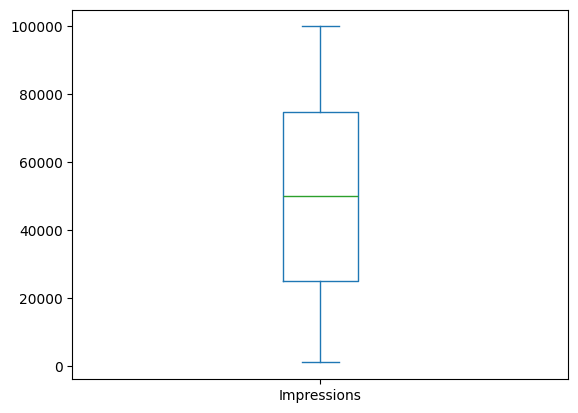

In [146]:
df["Impressions"].plot(kind="box")
plt.show()

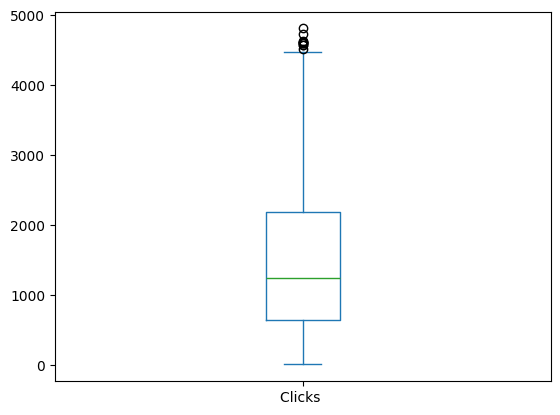

In [147]:
df["Clicks "].plot(kind="box")
plt.show()

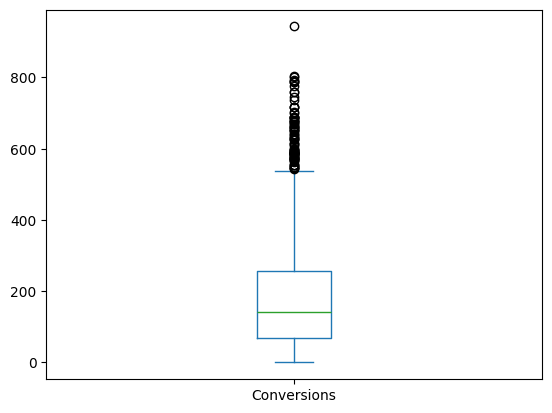

In [148]:
df["Conversions"].plot(kind="box")
plt.show()

In [149]:
df["Impressions"].skew()

np.float64(0.009348447530933151)

Impressions have near-zero skewness (0.009), indicating an approximately symmetric distribution.

In [150]:
df["Clicks "].skew()

np.float64(0.780937461256074)

Clicks show moderate positive skewness (0.781), indicating that a smaller number of campaigns have substantially higher click counts.

In [151]:
df["Conversions"].skew()

np.float64(1.3684537518853066)

Conversions show high positive skewness (1.368), indicating that most campaigns have relatively low conversion counts, with a smaller number of campaigns having substantially higher conversions.

In [182]:
numeric_columns = ["Impressions", "Clicks ", "Conversions"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Outliers: {len(outliers)}")
    print()



Impressions
Lower bound: -49592.62
Upper bound: 149410.38
Outliers: 0

Clicks 
Lower bound: -1651.00
Upper bound: 4487.00
Outliers: 11

Conversions
Lower bound: -215.50
Upper bound: 540.50
Outliers: 88



## Cross column consistency

In [152]:
pd.crosstab(
    df["Channel"],
    df["Campaign_Tag"]
)

Campaign_Tag,E-,EM,FA,GO,IN,INVALID,TI
Channel,,,,,,,
E-mail,20,0,0,0,0,1,0
Email,0,335,0,0,0,24,0
Facebok,0,0,13,0,0,1,0
Facebook,0,0,378,0,0,13,0
Gogle,0,0,0,13,0,1,0
Google Ads,0,0,0,324,0,22,0
Insta_gram,0,0,0,0,19,0,0
Instagram,0,0,0,0,324,16,0
TikTok,0,0,0,0,0,15,384


The cross-tabulation reveals recurring relationships between Channel labels and Campaign Tags, including TikTok/Tik_Tok → TI and Facebook/Facebok → FA. These relationships may help validate and standardize categorical values during cleaning.

## Missingness pattern

In [153]:
missing_rows = df[df.isna().any(axis=1)]
display(missing_rows.head(20))

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
5,CMP-00006,Q4_BlackFriday_CMP-00006,2023-10-15 00:00:00,2023-10-28,Instagram,83386,2643,2697.03,NaN,1,NaN,IN
6,CMP-00007,Q3_Launch_CMP-00007,2023-10-07 00:00:00,2023-10-23,Facebook,38194,1135,1232.76,178.0,Yes,NaN,FA
7,CMP-00008,Q4_Launch_CMP-00008,2023-05-23,2023-05-28,Instagram,88498,1173,865.7,127.0,1,NaN,IN
8,CMP-00009,Q4_BlackFriday_CMP-00009,2023-03-23 00:00:00,2023-04-01,Google Ads,45131,1179,1046.18,104.0,1,NaN,GO
9,CMP-00010,Q2_Winter_CMP-00010,2023-03-21 00:00:00,2023-04-01,Email,61263,1153,1623.56,NaN,0,NaN,EM


In [158]:
missing_pattern = df.isna().sum(axis=1).value_counts().sort_index()
display(missing_pattern)


,count
0,35
1,1697
2,280
3,8


Missingness is widespread across the dataset, with only 35 of 2,020 rows being completely populated.

In [159]:
missing_by_column = df.isna()

display(missing_by_column.head(20))

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,True,False
5,False,False,False,False,False,False,False,False,True,False,True,False
6,False,False,False,False,False,False,False,False,False,False,True,False
7,False,False,False,False,False,False,False,False,False,False,True,False
8,False,False,False,False,False,False,False,False,False,False,True,False
9,False,False,False,False,False,False,False,False,True,False,True,False


In [160]:
missing_patterns = (
    df.isna()
      .value_counts()
      .reset_index(name="row_count")
)

display(missing_patterns)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag,row_count
0,False,False,False,False,False,False,False,False,False,False,True,False,1692
1,False,False,False,False,False,False,False,False,True,False,True,False,189
2,False,False,False,False,True,False,False,False,False,False,True,False,91
3,False,False,False,False,False,False,False,False,False,False,False,False,35
4,False,False,False,False,True,False,False,False,True,False,True,False,8
5,False,False,False,False,False,False,False,False,True,False,False,False,3
6,False,False,False,False,True,False,False,False,False,False,False,False,2


In [161]:
df[
    df["Channel"].isna() &
    df["Conversions"].isna()
].shape[0]

8

In [162]:
df[
    df["Channel"].isna() &
    df["Clicks"].isna()
].shape[0]

99

In [166]:
df[
    df["Channel"].isna() &
    df["Clicks "].isna()
].shape[0]

0

In [163]:
df[
    df["Conversions"].isna() &
    df["Clicks"].isna()
].shape[0]

197

In [167]:
df[
    df["Conversions"].isna() &
    df["Clicks "].isna()
].shape[0]

0

In [165]:
df[
    df["Channel"].isna() &
    df["Conversions"].isna() &
    df["Clicks "].isna()
].shape[0]

0

# Checking if missingness is concentrated by segment.

In [168]:
channel_missing_by_tag = (
    df.groupby("Campaign_Tag")["Channel"]
      .apply(lambda x: x.isna().sum())
)

display(channel_missing_by_tag)

,Channel
Campaign_Tag,
E-,0
EM,0
FA,0
GO,0
IN,0
INVALID,8
TI,0
XX,93


In [169]:
channel_missing_by_tag = (
    df.groupby("Campaign_Tag")["Channel"]
      .agg(
          total_rows="size",
          missing_channel=lambda x: x.isna().sum()
      )
)

channel_missing_by_tag["missing_pct"] = (
    channel_missing_by_tag["missing_channel"]
    / channel_missing_by_tag["total_rows"]
    * 100
).round(2)

display(channel_missing_by_tag)

,total_rows,missing_channel,missing_pct
Campaign_Tag,,,
E-,20,0,0.00
EM,335,0,0.00
FA,391,0,0.00
GO,337,0,0.00
IN,343,0,0.00
INVALID,101,8,7.92
TI,400,0,0.00
XX,93,93,100.00


In [172]:
conversion_missing_by_channel = (
    df.groupby("Channel")["Conversions"]
      .agg(
          total_rows="size",
          missing_conversions=lambda x: x.isna().sum()
      )
)

conversion_missing_by_channel["missing_pct"] = (
    conversion_missing_by_channel["missing_conversions"]
    / conversion_missing_by_channel["total_rows"] * 100
).round(2)

display(conversion_missing_by_channel)

,total_rows,missing_conversions,missing_pct
Channel,,,
E-mail,21,2,9.52
Email,359,32,8.91
Facebok,14,1,7.14
Facebook,391,38,9.72
Gogle,14,2,14.29
Google Ads,346,33,9.54
Insta_gram,19,3,15.79
Instagram,340,41,12.06
TikTok,399,40,10.03


# Summary of Data Profiling Findings

## 1. Dataset Overview

* The raw dataset contains **2,020 rows and 12 columns**.
* The dataset contains campaign identifiers, campaign details, dates, channel information, performance metrics, spend, status, and campaign tags.

## 2. Structural and Integrity Findings

* Several column names contain leading or trailing whitespace, including `Campaign_ID` and `Clicks`.
* Two Clicks-related columns are present:

  * `Clicks ` (trailing space): **2,020 non-null values** and `int64` type.
  * `Clicks` (no trailing space): only **40 non-null values**, with **1,980 missing values**.
* The sparse `Clicks` column has substantially different values from the primary `Clicks ` field and requires investigation before being used for analysis.
* The dataset contains **19 exact duplicate rows**.
* `Campaign_ID` contains **2,000 unique values across 2,020 rows**, indicating repeated campaign IDs.
* No `Campaign_ID` was found to be associated with multiple `Campaign_Name` values.

## 3. Missing-Value Findings

* `Clicks` (sparse column): **1,980 missing values (98.02%)**.
* `Conversions`: **200 missing values (9.90%)**.
* `Channel`: **101 missing values (5.00%)**.
* **1,985 rows** contain at least one missing value.
* **288 rows** contain two or more missing values.
* Only **35 rows** contain no missing values.
* Missingness is concentrated in specific patterns, particularly involving the sparse `Clicks` column.
* `Channel` missingness is highly concentrated in `Campaign_Tag = XX`, where **93 of 93 rows have missing Channel values**.

## 4. Categorical Findings

### Channel

* There are **10 distinct non-null Channel labels**.
* Several labels appear to represent the same underlying channel, including:

  * `TikTok` / `Tik_Tok`
  * `Facebook` / `Facebok`
  * `Instagram` / `Insta_gram`
  * `Google Ads` / `Gogle`
  * `Email` / `E-mail`
* These inconsistencies require standardization during the cleaning stage.

### Active

* `Active` contains seven representations of boolean states:

  * `1`, `0`
  * `Yes`, `No`
  * `True`, `False`
  * `Y`
* These values require standardization before analysis.

### Campaign Tag

* `Campaign_Tag` contains eight values.
* `INVALID`, `XX`, and `E-` appear to be invalid or non-standard tags and require investigation.

## 5. Date Findings

* `Start_Date` and `End_Date` are initially stored as `object` values.
* `Start_Date` contains mixed representations, including datetime strings, date-only strings, and slash-formatted dates.
* Both date columns were successfully parsed using `format="mixed"` with `dayfirst=True`, resulting in **zero parsing failures** under that interpretation.
* However, **78 records have `End_Date` earlier than `Start_Date`**, violating the expected campaign-duration relationship.

## 6. Business Rule Findings

* The sparse `Clicks` column contains **40 records where Clicks exceed Impressions**, violating the expected relationship `Clicks ≤ Impressions`.
* The primary `Clicks ` column contains **no records where Clicks exceed Impressions**.
* No records were found where `Conversions` exceed the primary `Clicks ` value.
* No records were found where `Conversions` exceed the sparse `Clicks` value.
* The **78 invalid date relationships** identified above require investigation.

## 7. Numeric, Distribution and Outlier Findings

* `Impressions` has near-zero skewness (**0.009**), indicating an approximately symmetric distribution. The IQR method identified **0 potential outliers**.
* Primary `Clicks ` has moderate positive skewness (**0.781**). The IQR method identified **11 potential outliers**, with values exceeding the upper bound of **4,487**.
* `Conversions` has stronger positive skewness (**1.368**). The IQR method identified **88 potential outliers**, with values exceeding the upper bound of **540.5**.
* The identified outliers should be investigated during the cleaning and EDA stages rather than automatically removed, as unusually high campaign performance may represent legitimate observations.
* The distribution analysis indicates that `Conversions` is more heavily right-skewed than `Clicks `, while `Impressions` is approximately symmetric.


## 8. Spend Findings

* `Spend` is stored as an `object` rather than a numeric data type.
* The column contains mixed representations, including values with currency symbols such as `$102.82` and numeric-looking strings such as `24.33`.
* **298 values contain currency symbols or separators**, indicating inconsistent formatting.
* `Spend` contains negative values and need to be further investigated at source.

## 9. Cross-Column Consistency Findings

* `Channel` and `Campaign_Tag` generally show expected relationships, such as:

  * TikTok / Tik_Tok → `TI`
  * Facebook / Facebok → `FA`
  * Instagram / Insta_gram → `IN`
  * Google Ads / Gogle → `GO`
  * Email → `EM`
* However, several records contain `INVALID` or `XX` tags, and some non-standard channel labels are present.
* This indicates that categorical standardization and validation are required during cleaning.

## 10. Cleaning Handoff

The profiling stage identified the following areas for investigation and cleaning:

1. Standardize column names and resolve the two Clicks-related fields.
2. Investigate and handle exact duplicate rows and repeated Campaign IDs.
3. Standardize inconsistent Channel labels.
4. Standardize `Active` into a consistent boolean representation.
5. Investigate and standardize invalid Campaign Tags.
6. Convert mixed-format date fields into consistent datetime values.
7. Investigate the 78 invalid Start Date / End Date relationships.
8. Determine an appropriate treatment for missing `Channel` and `Conversions` values.
9. Investigate the sparse `Clicks` column and its 40 non-null values before deciding whether to retain, merge, or remove it.
10. Standardize the `Spend` field into a numeric representation.
11. Review potential numeric outliers during the cleaning and EDA stages.

**Conclusion:** The raw dataset contains multiple structural, completeness, consistency, formatting, and business-rule issues that should be resolved before downstream analysis. The findings from this notebook will serve as the basis for the subsequent **data cleaning and transformation stage**.
